# AB TESTING OF TRADING PLATFROM SOLLMAFIN
### Issued: Oleg Khe
### date: 16.09.2025

# Study of A/B Test Results and Finding Insights

SollmaFin is an international mobile application for online trading of financial assets. Users can invest money in stocks, currency, cryptocurrency, exchange-traded funds (ETFs), and other assets. The target audience of the app is beginner investors. Access to financial markets is available via smartphone or through the web version.

The app is focused on the Latin American market, with an emphasis on four countries: Mexico, Brazil, Colombia, and Argentina — where interest in fintech and investments is growing rapidly, and the economies are very diverse.

A hypothesis emerged regarding users' insufficient financial literacy: they do not understand how to work with assets of different risk levels. Clients buy high-risk assets and lose money, which reduces engagement.
The product team decided to update the user onboarding process and add detailed information about the differences between financial assets and their associated risks. However, there was concern that in-depth onboarding might scare clients away from making deposits and from riskier investments.

To investigate, the team decided to run an A/B experiment.

### A/B Experiment

New users who registered in the app from June 2 to June 15, 2025, participated in the experiment.
Users were randomly divided into two equal groups:
- The **Control Group** went through the standard onboarding without mandatory education.
- The **Test Group** went through the updated onboarding with detailed information about assets and their associated risks.

After the split, user activity was analyzed for one week.

The goal of the experiment was to assess how the updated onboarding affects user behavior and their subsequent investment activity.

When implementing the new feature, the product team proposed the following hypotheses:
- **Growth Hypothesis:** Educational onboarding helps users better understand investment principles, so they will be more likely to open a second deposit.
- **Risk Hypothesis:** Information about potential losses and high risks might deter some beginners, especially the most cautious ones, which could reduce conversion to the first deposit.
- **Additional Hypothesis:** After the new onboarding, users who choose high-risk assets will be more likely than before to return and open a second deposit. With the old onboarding, users often purchased high-risk assets without understanding the consequences. This led to losses and churn after the first deposit.

To see the full picture, tracking only conversion metrics is insufficient. The team selected the following set of metrics for the experiment:
- **Key Metric:** Average total deposits per user (including those who installed the app or opened the web version).
- **Guardrail Metric:** Conversion from registration to first deposit.
- **Secondary Metric 1:** Conversion from first deposit to second deposit.
- **Secondary Metric 2:** Average total deposits per user who opened at least one deposit.

It was expected that the key and guardrail metrics would not decline, while the secondary metrics would show significant growth.

### Analyst's Tasks

To conduct a complete analysis of the A/B experiment results. But first, you need to dive into the product and study the historical data.


#### 1. Analysis of Historical Data

To understand why the new feature was developed:
- Behavior of new users, including acquisition dynamics, segmentation, and key stages of the action funnel.
- Metrics related to making deposits, including average deposit amounts.

#### 2. Analysis of A/B Test Data

Studying the experiment results will consist of two stages:
- Comparing user behavior in the control and test groups, assessing the statistical significance of changes.
- Investigating the impact of the new onboarding on paying users' behavior. In this investigation, I will use bootstrap and focus on the lower and upper percentiles of the deposit distribution.
- This approach will allow to understand how the updated onboarding affected key business metrics, identify growth points, and formulate recommendations for improving user experience and monetization.


### Data

Two datasets:

1.  The dataset `/datasets/pa_sollmafin_hist.csv` contains historical data on key actions of new users acquired between April 1 and June 1, 2025, inclusive. The dataset includes user actions up to the moment of making a second deposit.
2.  The dataset `/datasets/pa_sollmafin_abt.csv` contains A/B experiment data — all actions of new users who registered from June 2 to June 15, 2025, inclusive. The data was collected to test the hypothesis about the impact of the new onboarding on user behavior and activity. Users are already assigned to A/B experiment groups.

**Common Fields in Datasets:**
- `user_id` — unique user identifier;
- `country_code` — user's country code in ISO format (e.g., `BR` — Brazil, `MX` — Mexico, `AR` — Argentina, `CO` — Colombia);
- `platform` — device the user interacts with the product on: `mobile` or `web`;
- `first_ts` — timestamp of the user's first appearance in the system;
- `first_dt` — date of the user's first appearance (without time);
- `event_ts` — timestamp of the event;
- `event_name` — name of the event;
- `amount` — deposit amount;
- `asset` — type of asset purchased;
- `risk_level` — risk level of the asset: `low`, `medium`, `high`.

The dataset `/datasets/pa_sollmafin_abt.csv` contains two additional fields:
- `ab_test` — name of the A/B experiment;
- `group` — user's A/B experiment group.


### Project Plan
1.  Loading historical data and its preprocessing
2.  Exploratory analysis of historical data
3.  Investigation of A/B experiment results
4.  Analysis of changes in the amount of deposits per paying user
5.  Conclusions

---

## Part 1

### 1. Loading Historical Data and Its Preprocessing

Load the data from the `/datasets/pa_sollmafin_hist.csv` dataset and obtain basic information about it. Perform preprocessing. Record the main information about the data and preprocessing in a brief intermediate conclusion.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt
import numpy as np
from sklearn.cluster import KMeans
from statsmodels.stats.proportion import proportions_ztest

In [5]:
hist_data=pd.read_csv( 'https://code.s3.yandex.net/datasets/pa_sollmafin_hist.csv', parse_dates=['first_dt',
'first_ts', 'event_ts'])

In [6]:
hist_data.describe()

,first_ts,first_dt,event_ts,amount
count,238059,238059,238059,33093.000000
mean,2025-05-02 01:15:55.141006848,2025-05-01 09:56:10.897130752,2025-05-02 14:07:17.970582784,113.527967
min,2025-04-01 00:06:34,2025-04-01 00:00:00,2025-04-01 00:06:34,27.000000
25%,2025-04-16 13:58:16,2025-04-16 00:00:00,2025-04-17 00:09:02,90.000000
50%,2025-05-01 21:35:50,2025-05-01 00:00:00,2025-05-02 12:55:17,109.000000
75%,2025-05-17 14:57:18,2025-05-17 00:00:00,2025-05-18 02:21:01,131.000000
max,2025-06-01 23:59:52,2025-06-01 00:00:00,2025-06-09 20:24:42,524.000000
std,NaN,NaN,NaN,34.472458


In [7]:
hist_data.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


In [8]:
hist_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB


###### Checking for duplicates

In [10]:
hist_data.shape[0] - len( hist_data.drop_duplicates() )

0

###### Checking for duplicates. Implicit

In [12]:
## matches by time and event name:
( hist_data.groupby(['user_id', 'event_name'])['event_ts'].filter(lambda x: x.nunique() > 1)).head()

Series([], Name: event_ts, dtype: datetime64[ns])

No implicit duplicates found.

Data from 238k rows of events turns into 33k rows of purchases, having a normal distribution. With an average level of 113 per purchase, the 75th percentile is 131 . There are gaps in the asset description lines. They cannot be replaced, as the data is generally intended for testing. No duplicates were found in the data.

---

### 2. Exploratory Analysis of Historical Data

Conduct an exploratory analysis of the historical data. For each subtask, make an intermediate conclusion.

**Task 2.1.** Analysis of new users.
- Study the dynamics of attracting new users to the application.

In [15]:
user_dynamic=hist_data.groupby([pd.to_datetime(hist_data['first_dt']).dt.date, 'country_code', 
                                'platform']) ['user_id'].nunique().reset_index(name = 'users')
user_dynamic.head()

,first_dt,country_code,platform,users
0,2025-04-01,AR,mobile,86
1,2025-04-01,AR,web,42
2,2025-04-01,BR,mobile,143
3,2025-04-01,BR,web,58
4,2025-04-01,CO,mobile,115


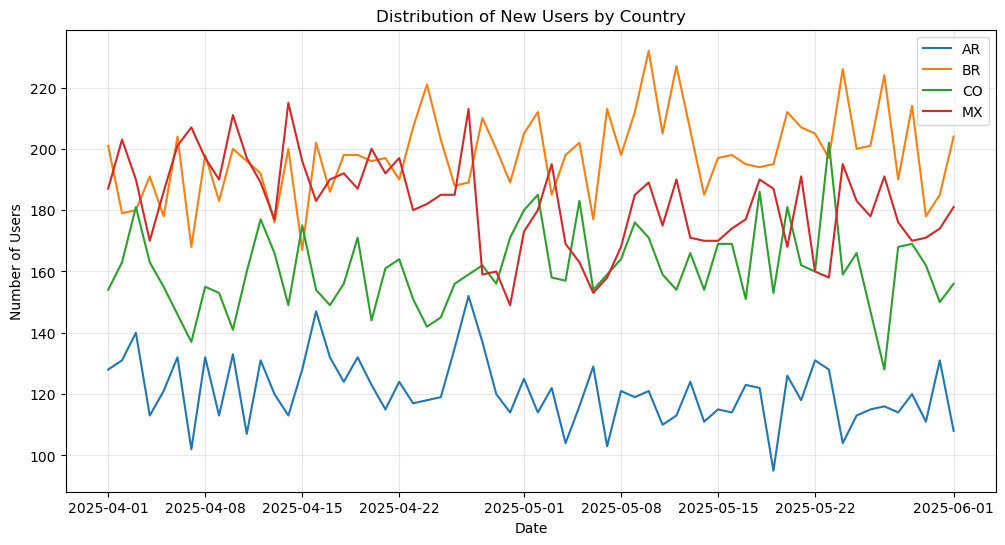

In [16]:
plt.figure(figsize=(12, 6))
for country in user_dynamic['country_code'].unique():
    user_dynamic_country = user_dynamic[user_dynamic['country_code'] == country].groupby('first_dt')['users'].sum().reset_index()
    plt.plot(user_dynamic_country['first_dt'], user_dynamic_country['users'], label = country )

plt.title('Distribution of New Users by Country')
plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The trend across countries is stable; there is a difference in absolute numbers, but no pronounced dynamics. Volatility is insignificant, around 10%. This indicates the stability of the interface and algorithm.

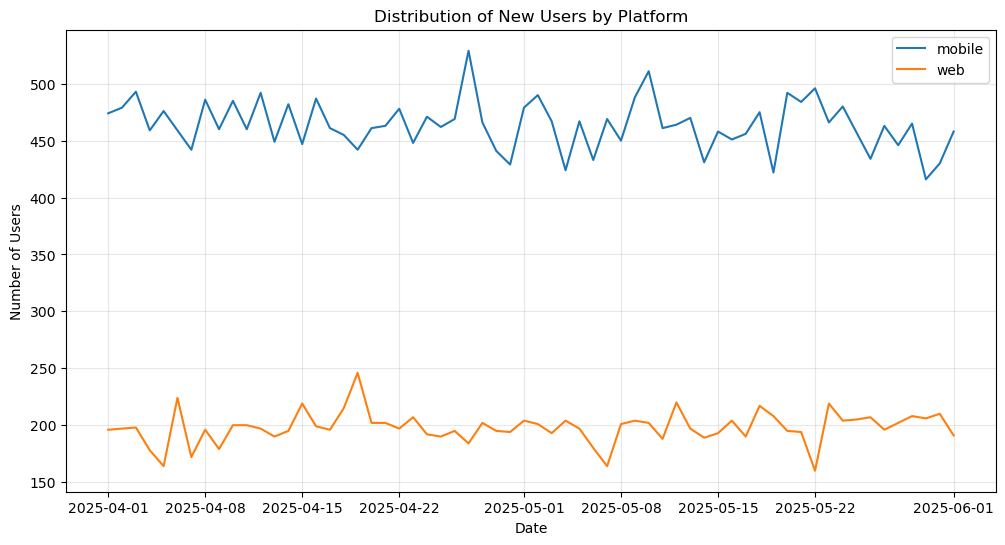

In [18]:
plt.figure(figsize=(12, 6))
for platform in user_dynamic['platform'].unique():
    user_dynamic_platform = user_dynamic[user_dynamic['platform'] == platform].groupby('first_dt')['users'].sum().reset_index()
    plt.plot(user_dynamic_platform['first_dt'], user_dynamic_platform['users'], label = platform )

plt.title('Distribution of New Users by Platform')
plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

There is also no pronounced dynamics by platform. It can be seen that the number of mobile users is higher than that of PC users, by approximately 2.5 times.

**Task 2.2.** Analysis of Event Funnels.
- Build a classic and a step-by-step funnel;
- Describe the user journey in the application and identify the bottlenecks in the funnel.


In [21]:
events=hist_data['event_name'].unique().tolist()
platforms=hist_data['platform'].unique().tolist()
hist_data_country = hist_data.groupby(['event_name','country_code'])['user_id'].nunique().reset_index(name = 'users_num')
hist_data_country_1st_ev = hist_data_country[hist_data_country['event_name']==events[0]]
hist_data_country_1st_ev

,event_name,country_code,users_num
8,install / open_web,AR,7489
9,install / open_web,BR,12266
10,install / open_web,CO,9974
11,install / open_web,MX,11303


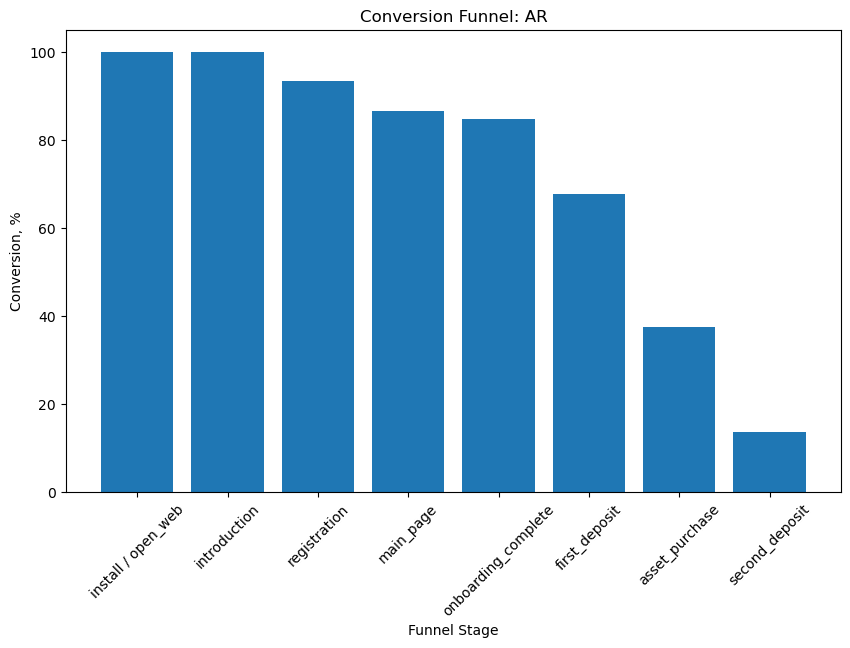

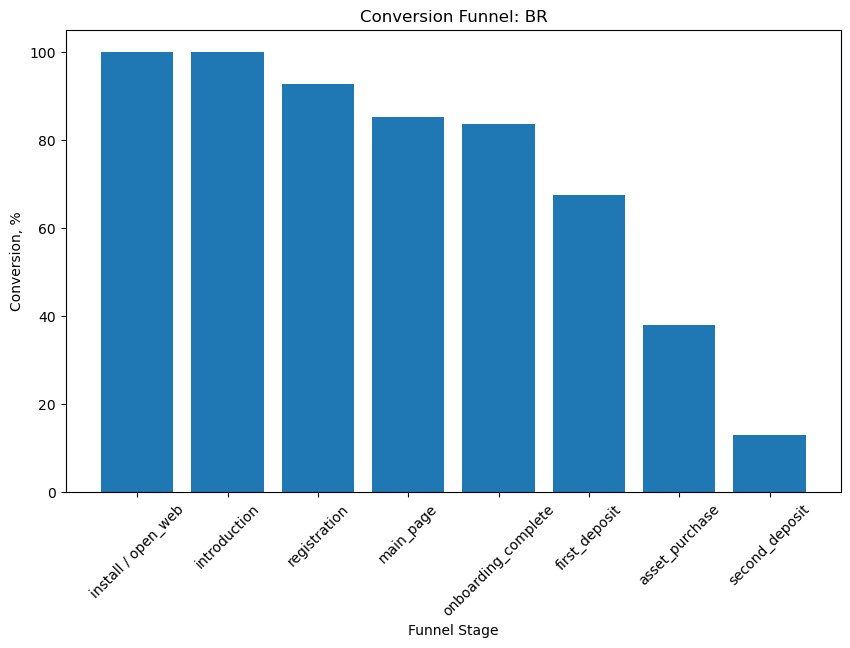

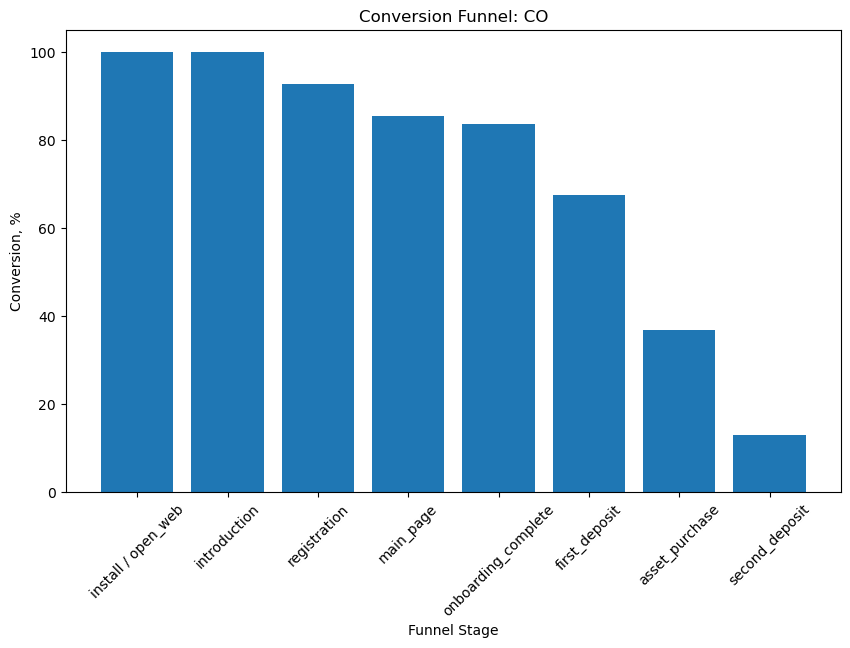

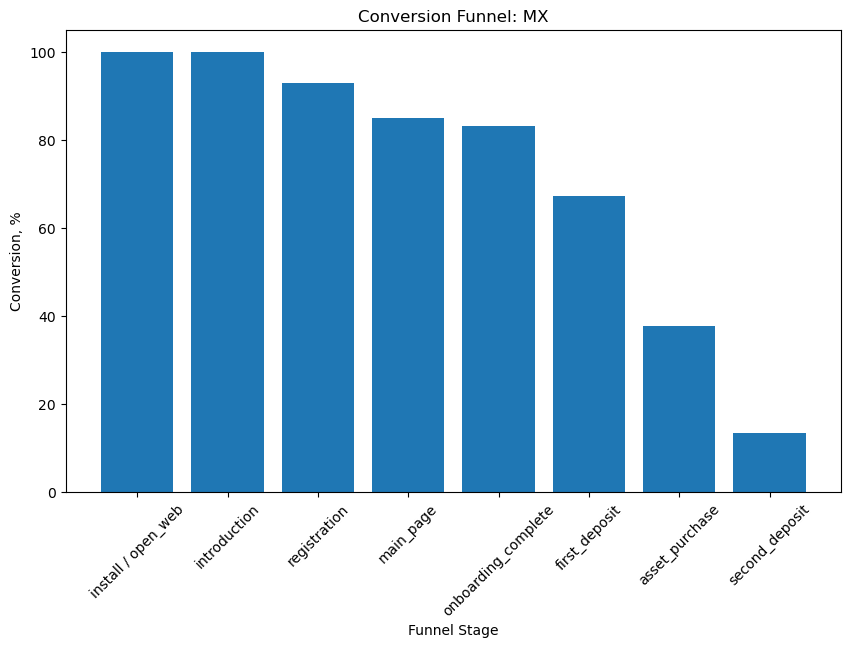

In [22]:
hist_data_group = hist_data.groupby(['event_name','platform', 'country_code'])['user_id'].nunique().reset_index(name = 'users_num')
hist_data_group_country = hist_data_group.groupby(['event_name', 'country_code'])['users_num'].sum().reset_index()
hist_data_group_country = pd.merge(hist_data_group_country, hist_data_country_1st_ev, on = ['country_code'], how= 'left')
hist_data_group_country['conversion'] = 100 * hist_data_group_country['users_num_x'] / hist_data_group_country['users_num_y']
hist_data_group_country=hist_data_group_country.drop(['users_num_x','event_name_y', 'users_num_y'], axis = 1)
hist_data_group_country=hist_data_group_country.rename(columns={'event_name_x': 'event'})
pivot_country = hist_data_group_country.pivot_table(index = 'event', columns = 'country_code', values = 'conversion', aggfunc = 'first').loc[events]

for country in pivot_country.columns:
    plt.figure(figsize=(10, 6))
    plt.bar(pivot_country.index, pivot_country[country])
    plt.title(f'Conversion Funnel: {country}')
    plt.xlabel('Funnel Stage')
    plt.ylabel('Conversion, %')
    plt.xticks(rotation=45)
    plt.show()


The funnel shows a similar trend in all countries: a sharp drop in conversion after the first deposit. Let's build a step-by-step funnel.

In [24]:
hist_data_group = hist_data.groupby(['event_name','platform', 'country_code'])['user_id'].nunique().reset_index(name = 'users_num')
hist_data_group_country = hist_data_group.groupby(['event_name', 'country_code'])['users_num'].sum().reset_index()
##hist_data_group_country.pivot_table(index = 'event', columns = 'country_code', values = 'conversion', aggfunc = 'first').loc[events]
pivot_country = hist_data_group_country.pivot_table(index = 'event_name', columns = 'country_code', values = 'users_num', aggfunc = 'first').loc[events].reset_index() #.apply(pd.to_numeric, errors='coerce')
pivot_country.set_index('event_name', inplace=True)
pivot_country = pivot_country.apply(pd.to_numeric, errors='coerce')


In [25]:
results = []

for country in pivot_country.columns:
    country_data = pivot_country[country]
    conversion = (country_data / country_data.shift(1)) * 100
    
    for event in events[1:]:  
        results.append({
            'country': country,
            'event': event,
            'conversion': conversion.get(event, 0),
            'users': country_data.get(event, 0)
        })

conversion_df = pd.DataFrame(results)

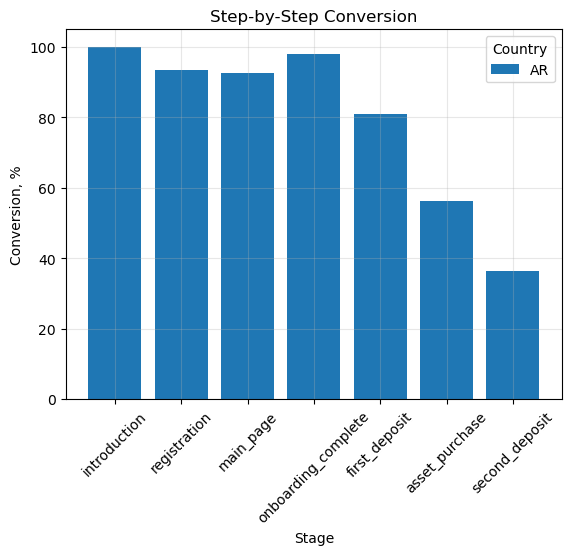

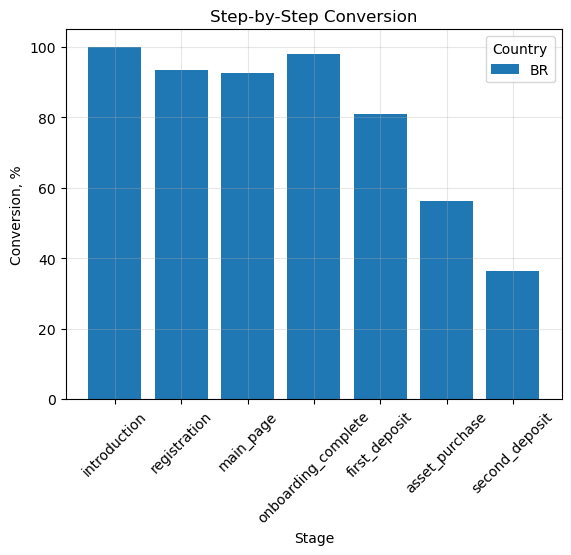

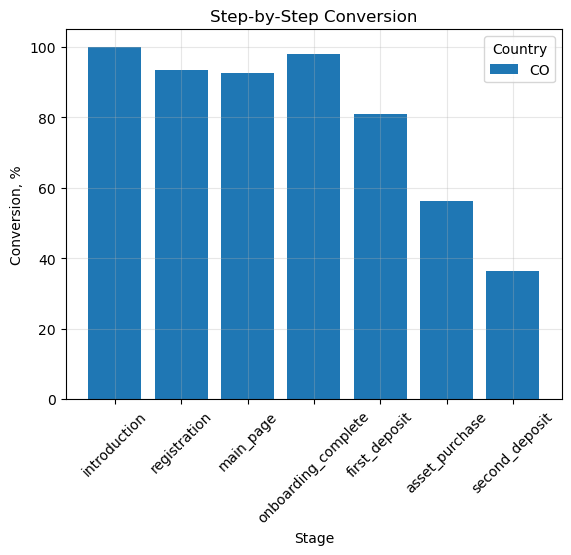

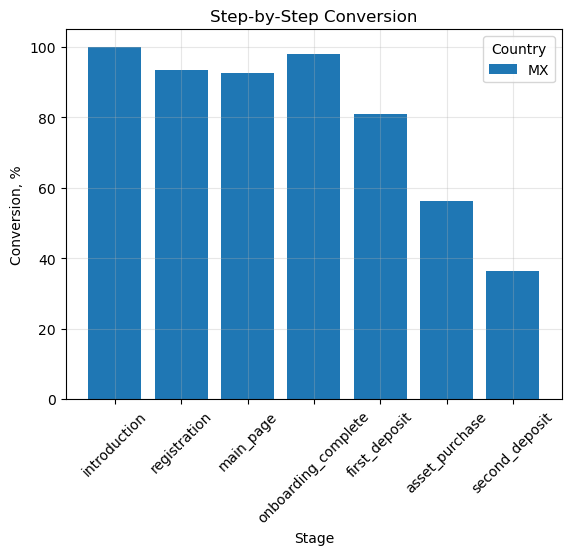

In [26]:
for country in conversion_df['country'].unique():
    plt.bar(conversion_df['event'], conversion_df['conversion'], label = country)
    plt.title('Step-by-Step Conversion')
    plt.xlabel('Stage')
    plt.ylabel('Conversion, %')
    plt.legend(title='Country')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.show()

Just in case, let's also look at the platforms.

<Axes: title={'center': 'User Funnel by Platform'}, xlabel='stages', ylabel='number of users'>

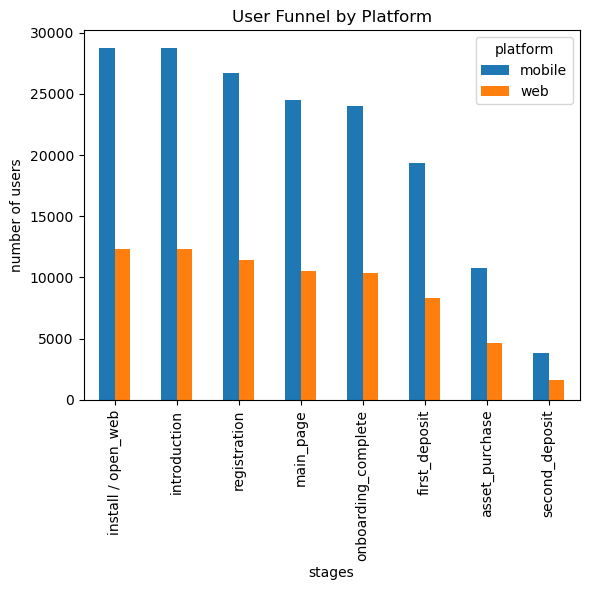

In [28]:
hist_data_group = hist_data.groupby(['event_name','platform', 'country_code'])['user_id'].nunique().reset_index(name = 'users_num')
hist_data_group_platform = hist_data_group.groupby(['event_name', 'platform'])['users_num'].sum().reset_index()
pivot_platform = hist_data_group_platform.pivot_table(index = 'event_name', columns = 'platform', values = 'users_num', aggfunc = 'first').loc[events].reset_index()
pivot_platform.set_index('event_name', inplace=True)
pivot_platform = pivot_platform.apply(pd.to_numeric, errors='coerce')
pivot_platform.plot(kind='bar', xlabel = 'stages', ylabel = 'number of users', title = 'User Funnel by Platform')

The classic funnel shows the same dynamics across platforms. After the first deposit, the number of users decreases.

In [30]:
results = []

for platform in pivot_platform.columns:
    platform_data = pivot_platform[platform]
    conversion = (platform_data / platform_data.shift(1)) * 100
    
    for event in events[1:]:  #
        results.append({
            'platform': platform,
            'event': event,
            'conversion': conversion.get(event, 0),
            'users': country_data.get(event, 0)
        })

pl_conversion_df = pd.DataFrame(results)
pl_conversion_df.head()

,platform,event,conversion,users
0,mobile,introduction,100.000000,11303
1,mobile,registration,92.916754,10511
2,mobile,main_page,91.721867,9599
3,mobile,onboarding_complete,97.955853,9403
4,mobile,first_deposit,80.689770,7600


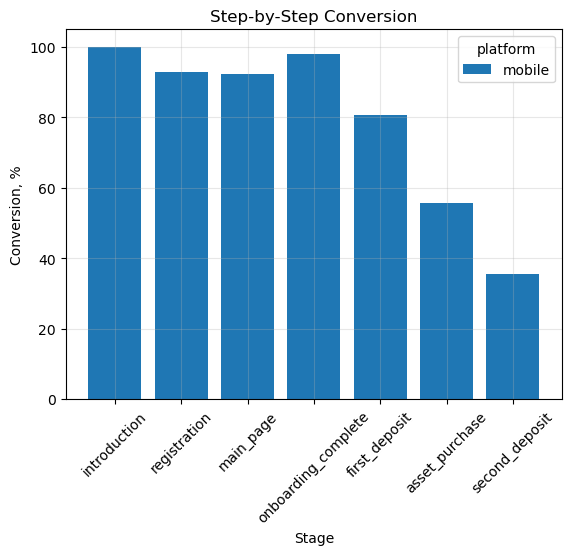

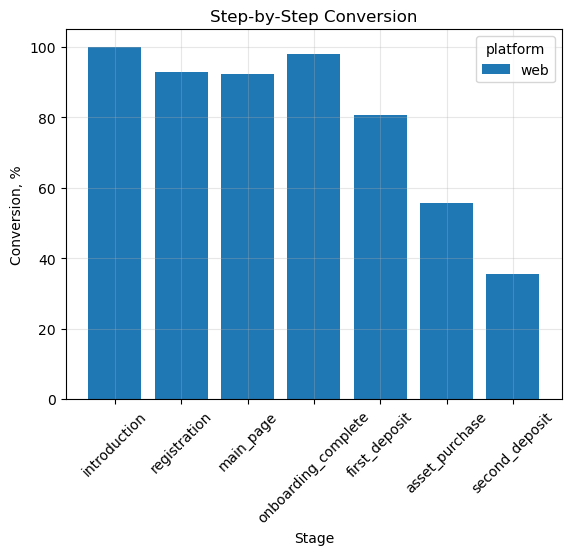

In [31]:
for platform in pl_conversion_df['platform'].unique():
    plt.bar(pl_conversion_df['event'], pl_conversion_df['conversion'], label = platform)
    plt.title('Step-by-Step Conversion')
    plt.xlabel('Stage')
    plt.ylabel('Conversion, %')
    plt.legend(title='platform')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.show()

The step-by-step conversion shows the same sharply declining dynamics for each country after the first deposit. The information is identical across countries.

The bottlenecks in the funnel are the purchase and the second deposit. It is clear that these are related outcomes; without purchases, there will be no deposits. It is necessary to test the theory about risk stopping purchases.

Text(0, 0.5, '% repeat purchases')

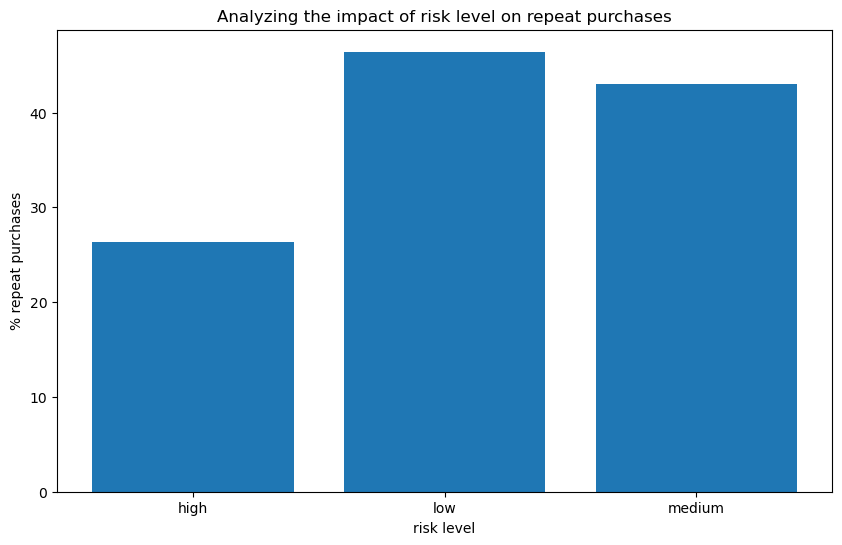

In [33]:
hist_data_group_risk = hist_data[hist_data['risk_level'].notna()]
hist_data_group_2nd_pay = hist_data[hist_data['event_name'] == 'second_deposit']
hist_data__2nd_pay = pd.merge(hist_data_group_2nd_pay['user_id'], hist_data_group_risk[['user_id','risk_level']],  on = 'user_id', how = 'left')
plt.figure(figsize=(10, 6))
purchase_by_risk=(100*hist_data__2nd_pay.groupby('risk_level')['user_id'].nunique() / hist_data_group_risk.groupby('risk_level')['user_id'].nunique()).fillna(0)
plt.bar(purchase_by_risk.index, purchase_by_risk.values)
plt.title("Analyzing the impact of risk level on repeat purchases")
plt.xlabel('risk level')
plt.ylabel('% repeat purchases')

The impact is significant; high risk clearly deters users, but the medium level does not lag far behind the low level.

**Task 2.4.** Analysis of the Key Metric on Historical Data.
- Using historical data, calculate the value of the key metric — the average total deposits per user. Consider all users who interacted with the service. This will help establish the baseline monetization level.
- Visualize the data where necessary. Based on the results of the exploratory analysis, make a brief conclusion.

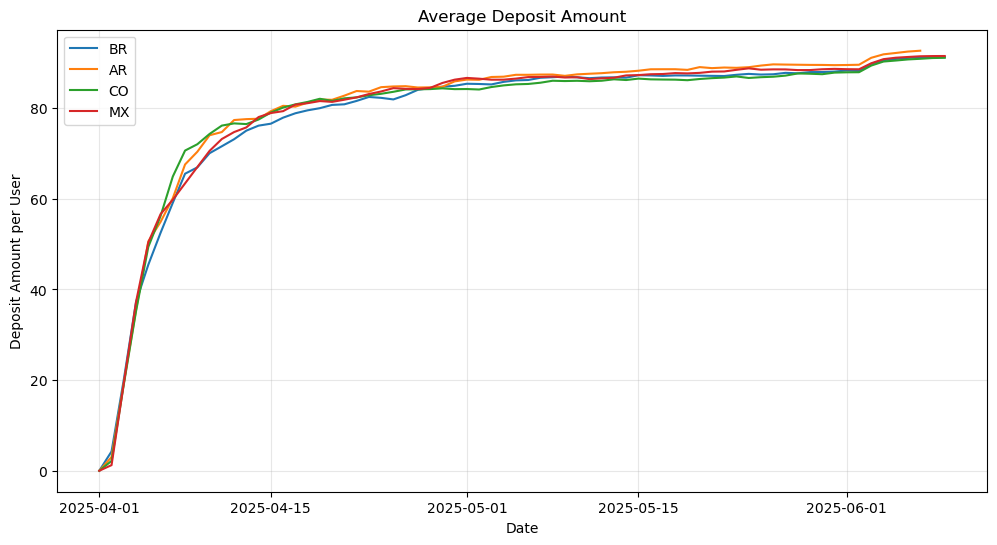

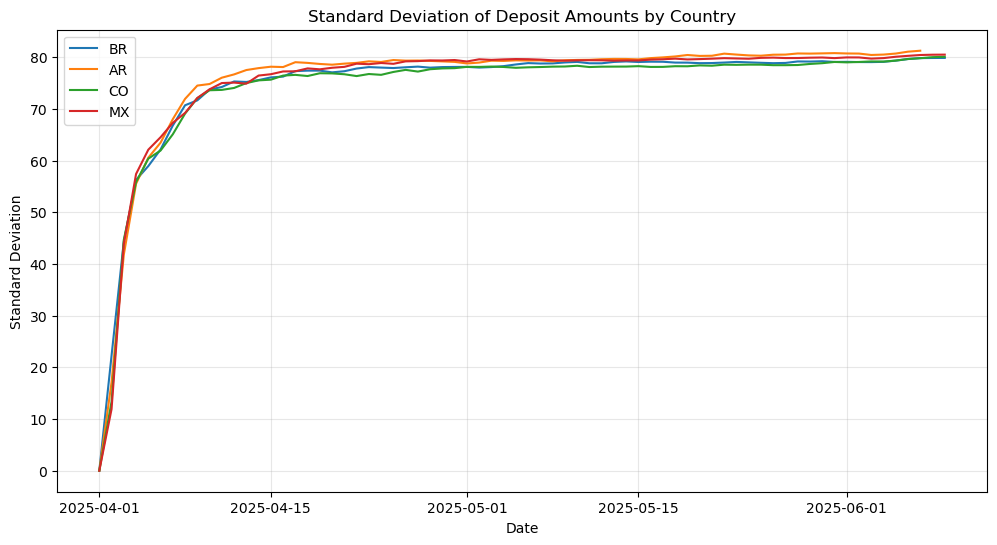

In [36]:
import warnings # import the library

warnings.filterwarnings('ignore')

plt.figure(figsize=(12, 6))
for country in hist_data['country_code'].unique():
    hist_datac = hist_data[hist_data['country_code'] == country].copy()
    avg_deposit_v=[]
    std_deposit_v = []
    before_dates = sorted(pd.to_datetime(hist_datac['event_ts']).dt.date.unique())
    for current_date in before_dates:
        current_date = pd.Timestamp(current_date)
        hist_data_date = hist_datac[pd.to_datetime(hist_datac['event_ts']) <= current_date]
    ## all registered users up to the current date
        users=hist_data_date['user_id'].nunique()
    ## all purchases up to the current date
        buys = hist_data_date['amount'].sum()     
    ## key metric for the current date: sum of deposits / number of unique users
        avg_deposit= buys/users
    
        avg_deposit_v.append({
        'date': current_date,
        'avg_deposit': avg_deposit
        })
    results_df = pd.DataFrame(avg_deposit_v).fillna(0)
    #print(results_df.head())
    
    plt.plot(results_df['date'], results_df['avg_deposit'], label = country)

plt.title("Average Deposit Amount")
plt.xlabel('Date')
plt.ylabel('Deposit Amount per User')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(12, 6))
for country in hist_data['country_code'].unique():
    hist_datac = hist_data[hist_data['country_code'] == country].copy()
    
    std_deposit_v = []
    before_dates = sorted(pd.to_datetime(hist_datac['event_ts']).dt.date.unique())
    for current_date in before_dates:
        current_date = pd.Timestamp(current_date)
        hist_data_date = hist_datac[pd.to_datetime(hist_datac['event_ts']) <= current_date]
    #
        users_deposits = hist_data_date.groupby('user_id')['amount'].sum()
        std_deposit = users_deposits.std() if len(users_deposits) > 1 else 0
        
        std_deposit_v.append({
        'date': current_date,
        'std_deposit': std_deposit
        })
    std_df = pd.DataFrame(std_deposit_v).fillna(0)
    plt.plot(std_df['date'], std_df['std_deposit'], label=country)

plt.title("Standard Deviation of Deposit Amounts by Country")
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A similar trend is visible across all countries: growth in the average deposit until mid-May 2024 (market entry period), followed by a steady upward trend and a slight jump from the beginning of June. The baseline monetization level reached about 95 units.

The standard deviation stabilizes around 80 across all countries in the historical period. With monetization at 95, the spread is very large (a significant distance from the mean). However, the indicator is identical across all countries!


---

## Part 2

### 3. Investigation of A/B Experiment Results
Load the data with the experiment results (dataset `/datasets/pa_sollmafin_abt.csv`). Check the data for correctness and perform preprocessing. Record the main information about the data and preprocessing in a brief intermediate conclusion.
Then, analyze the results of the A/B experiment.

In [39]:
test_data=pd.read_csv( 'https://code.s3.yandex.net/datasets/pa_sollmafin_abt.csv', parse_dates=['first_dt',
'first_ts', 'event_ts'])

In [40]:
test_data.describe()

,first_ts,first_dt,event_ts,amount
count,54805,54805,54805,7843.000000
mean,2025-06-09 02:35:07.728692992,2025-06-08 11:12:11.560988928,2025-06-09 15:31:20.440452608,109.620681
min,2025-06-02 00:27:50,2025-06-02 00:00:00,2025-06-02 00:27:50,25.000000
25%,2025-06-05 14:35:08,2025-06-05 00:00:00,2025-06-06 00:20:38,62.000000
50%,2025-06-08 22:27:05,2025-06-08 00:00:00,2025-06-09 15:32:06,97.000000
75%,2025-06-12 16:04:27,2025-06-12 00:00:00,2025-06-13 04:03:54,130.500000
max,2025-06-15 23:58:39,2025-06-15 00:00:00,2025-06-22 13:37:05,1050.000000
std,NaN,NaN,NaN,86.604702


In [41]:
test_data.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN


In [42]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB


###### checking for duplicates

In [44]:
test_data.shape[0] - len( test_data.drop_duplicates() )

0

In [45]:
## matches by time and event name:
( test_data.groupby(['user_id', 'event_name'])['event_ts'].filter(lambda x: x.nunique() > 1)).head()

Series([], Name: event_ts, dtype: datetime64[ns])

The data has been checked. No duplicates were found. Gaps in amounts and risk level are normal, as these are conversion results. There is no need to fill in the gaps, as statistical analysis is planned and the data is numerical.

**Task 3.1.** Analysis of the Experiment Audience.

In [48]:
## users with 1+ groups
test_data.groupby('user_id')['group'].filter(lambda x: x.nunique() > 1)

Series([], Name: group, dtype: object)

not available: no crossing

In [50]:
print(test_data.groupby('group')['user_id'].nunique())
print(100* test_data.groupby('group')['user_id'].nunique().min()/test_data.groupby('group')['user_id'].nunique().max())

group
control    4847
test       4568
Name: user_id, dtype: int64
94.24386218279348


The sample sizes differ by no more than 6%. This is a good result.

Text(0, 0.5, 'Number of Users')

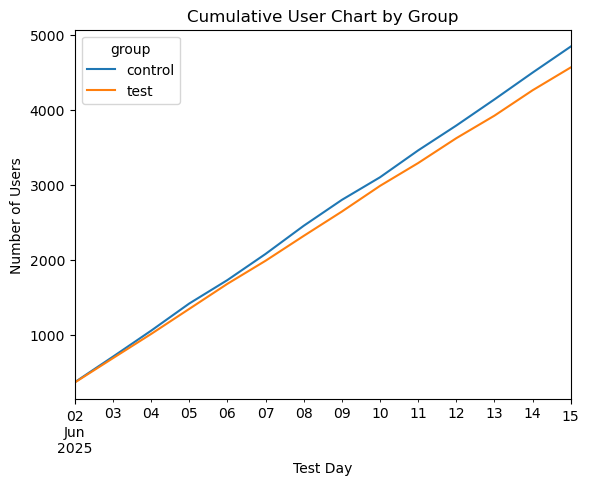

In [52]:
test_data.pivot_table(index = 'first_dt', columns = 'group', values = 'user_id', aggfunc = 'nunique').cumsum().plot()
plt.title('Cumulative User Chart by Group')
plt.xlabel("Test Day")
plt.ylabel("Number of Users")

The cumulative count grows almost synchronously; no instability (drops) was detected.

In [54]:
# Preliminary check of the average deposit amount

from scipy.stats import t
alpha =  0.025 # significance level
beta = 0.2 # test power
group_count = 2 # number of groups in the test
n_total = test_data['user_id'].nunique()
n = n_total / group_count  # size of one group
degrees_of_freedom = n_total - group_count  # degrees of freedom (total observations minus number of groups being compared)
mean = test_data.groupby('user_id')['amount'].sum().mean()
std = test_data.groupby('user_id')['amount'].sum().std()

t_alpha = t.ppf(1 - alpha /group_count , degrees_of_freedom)
t_beta = t.ppf(1 - beta, degrees_of_freedom)
left_factor = (t_alpha + t_beta) ** 2
right_factor = 2 * (std ** 2) / n
MDE = (left_factor * right_factor) ** 0.5
Relative_MDE = ((MDE / mean) * 100).round(2)

print(f"Relative MDE: {Relative_MDE}%")

Relative MDE: 7.71%


This value is higher than desirable for such a sample size, but it is acceptable. Therefore, we will apply the bootstrap method in the test.

**Task 3.2.** Comparison of Event Funnels.
- Compare the user journey of new users in the test and control groups.
- Build a classic and a sequential funnel, perform visualization, and make an intermediate conclusion.

In [57]:
test_pivot = test_data.pivot_table(index = ['event_name'], columns = 'group', values = 'user_id', aggfunc = 'nunique').loc[events]
test_pivot.head()

group,control,test
event_name,,
install / open_web,4847,4568
introduction,4847,4568
registration,4512,4265
main_page,4161,3919
onboarding_complete,4063,3462


In [58]:
first_event_control = test_pivot.index[0]
test_pivot.loc[first_event_control]

group
control    4847
test       4568
Name: install / open_web, dtype: int64

<Axes: title={'center': 'Classic Funnel'}, xlabel='Events', ylabel='conversion'>

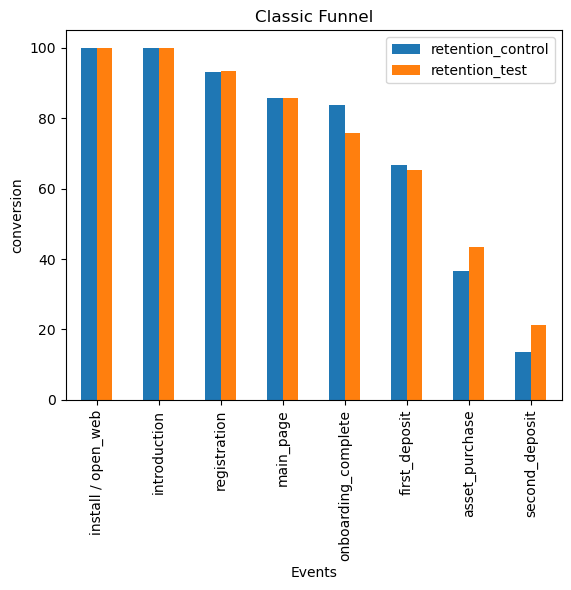

In [59]:
retention_d = []
for i in range(len(test_pivot.index)):
    retention = 100 * test_pivot.loc[test_pivot.index[i]] / test_pivot.loc[test_pivot.index[0]] 
    retention_d.append({'event_name': test_pivot.index[i], 'retention_control': retention.values[0], 'retention_test': retention.values[1]})
retention_df = pd.DataFrame(retention_d)
retention_df.plot(kind= 'bar', x = 'event_name', xlabel = 'Events', ylabel = 'conversion', title = 'Classic Funnel')

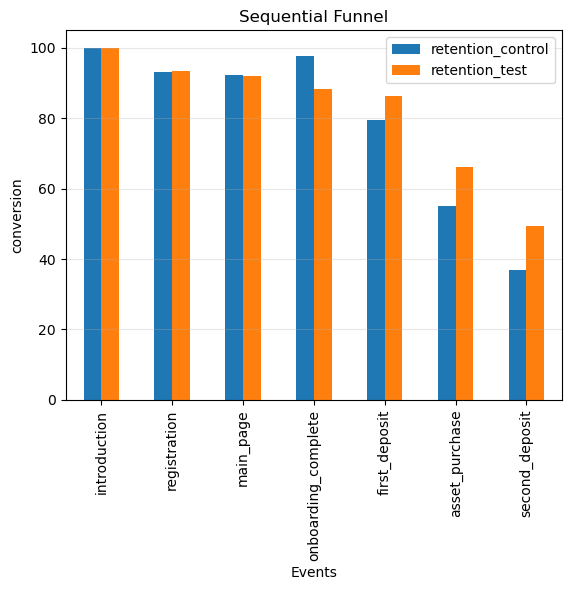

In [60]:
retention_d = []
for i in range(1, len(test_pivot.index)):
    retention = 100 * test_pivot.loc[test_pivot.index[i]] / test_pivot.loc[test_pivot.index[i-1]] 
    retention_d.append({'event_name': test_pivot.index[i], 'retention_control': retention.values[0], 'retention_test': retention.values[1]})
retention_df = pd.DataFrame(retention_d)
retention_df.plot(kind= 'bar', x = 'event_name', xlabel = 'Events', ylabel = 'conversion', title = 'Sequential Funnel')
plt.grid(axis='y', alpha=0.3)

##### Conclusion. In the test group, the values for the last steps — the number of users who made a second deposit — are higher than in the control group. This increase in the number of users is an indicator that could improve the target metric.

**Task 3.3.** The Impact of the New Feature on Second Deposit Conversion Considering the Risk Level of the Purchased Asset.
- Analyze how the risk category of the purchased asset affects the probability of opening a second deposit in the test and control groups.
- Compare the results and assess whether there is a statistically significant difference between the groups.

In [63]:
plt.figure(figsize=(10, 6))
group_data = {}
for group in test_data['group'].unique():
    test_data_group_risk = test_data[(test_data['group'] == group) & (test_data['risk_level'].notna())]
    
    test_data_group_2nd_pay = test_data[test_data['event_name'] == 'second_deposit']
    test_data__2nd_pay = pd.merge(test_data_group_2nd_pay['user_id'], test_data_group_risk[['user_id','risk_level']],  on = 'user_id', how = 'inner')
    purchase_by_risk=(100*test_data__2nd_pay.groupby('risk_level')['user_id'].nunique() / test_data_group_risk.groupby('risk_level')['user_id'].nunique()).fillna(0)
    group_data[group] = purchase_by_risk
conversion_df = pd.DataFrame(group_data)


<Figure size 1000x600 with 0 Axes>

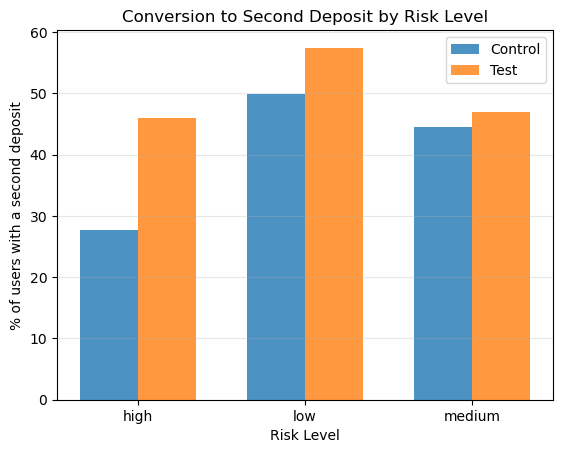

In [64]:
x = np.arange(len(conversion_df.index))
width = 0.35

plt.bar(x - width/2, conversion_df['control'], width, label='Control', alpha=0.8)
plt.bar(x + width/2, conversion_df['test'], width, label='Test', alpha=0.8)

plt.title("Conversion to Second Deposit by Risk Level")
plt.xlabel('Risk Level')
plt.ylabel('% of users with a second deposit')
plt.xticks(x, conversion_df.index)
plt.legend()
plt.grid(axis='y', alpha=0.3)

In [65]:
print(f"\nH0: The distribution of the metric 'Conversion to Second Deposit' is the same in both groups")
print(f"\nH1: The distribution of the metric 'Conversion to Second Deposit' is different")

from statsmodels.stats.power import TTestIndPower
a=test_data[test_data['risk_level'].notna()]
#a.groupby(['user_id', 'event_name'])['amount'].sum()
b=test_data[test_data['event_name']=='second_deposit']
c= a.merge(b[['user_id', 'event_name']], on = 'user_id', how = 'left')
c['is_second'] = c['event_name_y'].apply(lambda x: 0 if pd.isna(x) else 1)

for risk in sorted(c['risk_level'].unique()):
    c_risk = c [c['risk_level'] == risk]

    test_is_second = c_risk[c_risk['group']=='test']['is_second'].values
    control_is_second= c_risk[c_risk['group']=='control']['is_second'].values
    
    n_test = len(test_is_second)
    n_control = len(control_is_second)
    conversions_test = test_is_second.sum()
    conversions_control = control_is_second.sum()


    n_total = len(test_is_second) + len(control_is_second)
    group_count = 2
    n = n_total / group_count
    degrees_of_freedom = n_total - 2

## stat
    mean_test = test_is_second.mean()
    mean_control = control_is_second.mean()
    std_test = test_is_second.std()
    std_control = test_is_second.std()
    pooled_std = ((std_test ** 2 + std_control ** 2) / 2) ** 0.5

    conversion_test_rate = conversions_test / n_test
    conversion_control_rate = conversions_control / n_control
    lift = conversion_test_rate - conversion_control_rate
    relative_lift = lift / conversion_control_rate

    # Z-test
    count = np.array([conversions_test, conversions_control])
    nobs = np.array([n_test, n_control])
    z_stat, p_value = proportions_ztest(count, nobs)
    
    # Test power calculation
    effect = abs(lift) / pooled_std if pooled_std > 0 else 0
    power = TTestIndPower().solve_power(
        effect_size=effect, 
        nobs1=n_test, 
        alpha=alpha, 
        ratio=n_control/n_test
    ) if effect > 0 else 0

    print(f"\n{risk}: z-statistic = {z_stat:.4f}, p-value = {p_value:.6f}, test power: {power:.3f}")


H0: The distribution of the metric 'Conversion to Second Deposit' is the same in both groups

H1: The distribution of the metric 'Conversion to Second Deposit' is different

high: z-statistic = 7.6789, p-value = 0.000000, test power: 1.000

low: z-statistic = 2.0634, p-value = 0.039072, test power: 0.434

medium: z-statistic = 0.9141, p-value = 0.360690, test power: 0.093


The new feature primarily works for the high-risk group. There was an improvement in the test group based on the risk level. For the high-risk level, the indicator improved significantly by 15-18%, and this was statistically confirmed. For the other groups, the sample size is insufficient to detect an effect.

###### A value less than 1% indicates a significant difference in the data series, meaning the improvement is statistically significant.

Additionally, I will check the trends by country to ensure the absence of atypical behavior.

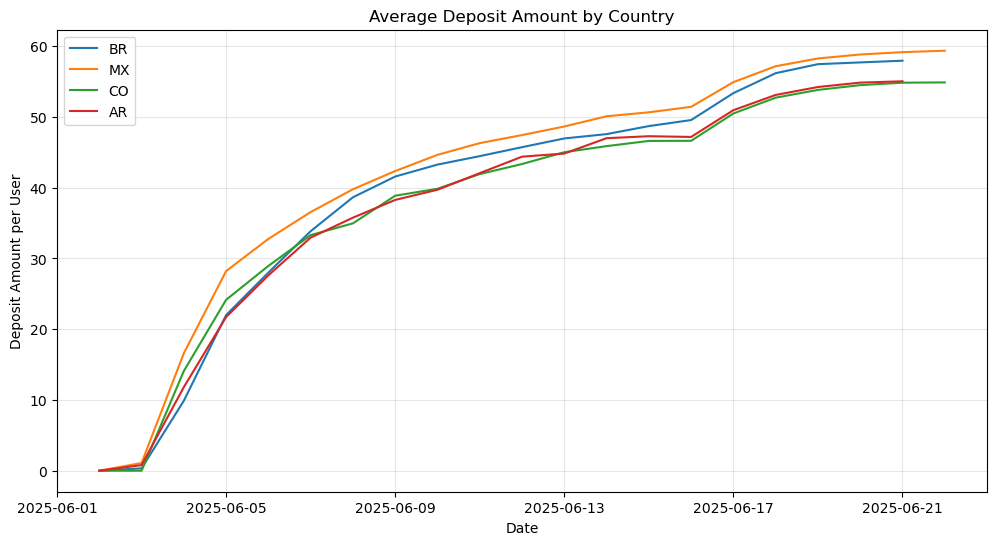

In [69]:
import warnings 
warnings.filterwarnings('ignore') #
plt.figure(figsize=(12, 6))
for country in test_data['country_code'].unique():
    test_datac = test_data[hist_data['country_code'] == country].copy()
    avg_deposit_v=[]
    before_dates = sorted(pd.to_datetime(test_datac['event_ts']).dt.date.unique())
    for current_date in before_dates:
        current_date = pd.Timestamp(current_date)
        test_data_date = test_datac[pd.to_datetime(test_datac['event_ts']) <= current_date]
    ## all registered users up to the current date
        users=test_data_date['user_id'].nunique()
    ## all purchases up to the current date
        buys = test_data_date['amount'].sum()     
    ## key metric for the current date: sum of deposits / number of unique users
        avg_deposit= buys/users   
        avg_deposit_v.append({
        'date': current_date,
        'avg_deposit': avg_deposit
        })
    results_df = pd.DataFrame(avg_deposit_v).fillna(0)
    #print(results_df.head())
    
    plt.plot(results_df['date'], results_df['avg_deposit'], label = country)
plt.title("Average Deposit Amount by Country")
plt.xlabel('Date')
plt.ylabel('Deposit Amount per User')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The trend across countries has been preserved, meaning no atypical behavior was detected.

**Task 3.4.** Analysis of A/B Experiment Metrics.
- **Key Metric:** Average total deposits per user (including those who installed the app or opened the web version).
- **Guardrail Metric:** Conversion from registration to first deposit.
- **Secondary Metric 1:** Conversion from first deposit to second deposit.
- **Secondary Metric 2:** Average total deposits per user who opened at least one deposit.

###### - Key Metric:** Average total deposits per user

In [73]:
print(f"\nH0: The distribution of the metric 'Deposit Amount per User' is the same in both groups")
print(f"\nH1: The distribution of the metric 'Deposit Amount per User' is different")

# main metric

import numpy as np
test_pivot = test_data.pivot_table(index = ['user_id'], columns = 'group', values = 'amount', aggfunc = 'sum').fillna(0)
control_amount_row=test_pivot.values[:, 0].astype(int)
test_amount_row=test_pivot.values[:, 1].astype(int)

## parameters
n_total = len(control_amount_row) + len(test_amount_row)
group_count = 2
n = n_total / group_count
degrees_of_freedom = n_total - 2

## stats
mean_test = test_amount_row.mean()
mean_control = control_amount_row.mean()
std_test = test_amount_row.std()
std_control = test_amount_row.std()
pooled_std = ((std_test ** 2 + std_control ** 2) / 2) ** 0.5

t_stat_lin = (mean_test - mean_control) / (pooled_std * (2 / n) ** 0.5)
p_value_lin = 2 * (1 - t.cdf(abs(t_stat_lin), degrees_of_freedom))
print(f"t-statistic = {t_stat_lin:.4f}, p-value = {p_value_lin:.4f}")


H0: The distribution of the metric 'Deposit Amount per User' is the same in both groups

H1: The distribution of the metric 'Deposit Amount per User' is different
t-statistic = -1.0382, p-value = 0.2992


The negative value indicates a decrease in the indicator. Let's check the change in average values:

In [75]:
print(f"Average deposit amount per user in the control group: {control_amount_row.mean()}\n Average deposit amount per user in the test group: {test_amount_row.mean()}\n Absolute change: {test_amount_row.mean()-control_amount_row.mean()}\n Relative change %: {100*(test_amount_row.mean()-control_amount_row.mean())/control_amount_row.mean()}")

Average deposit amount per user in the control group: 46.457142857142856
 Average deposit amount per user in the test group: 44.860435475305366
 Absolute change: -1.59670738183749
 Relative change %: -3.436947008875286


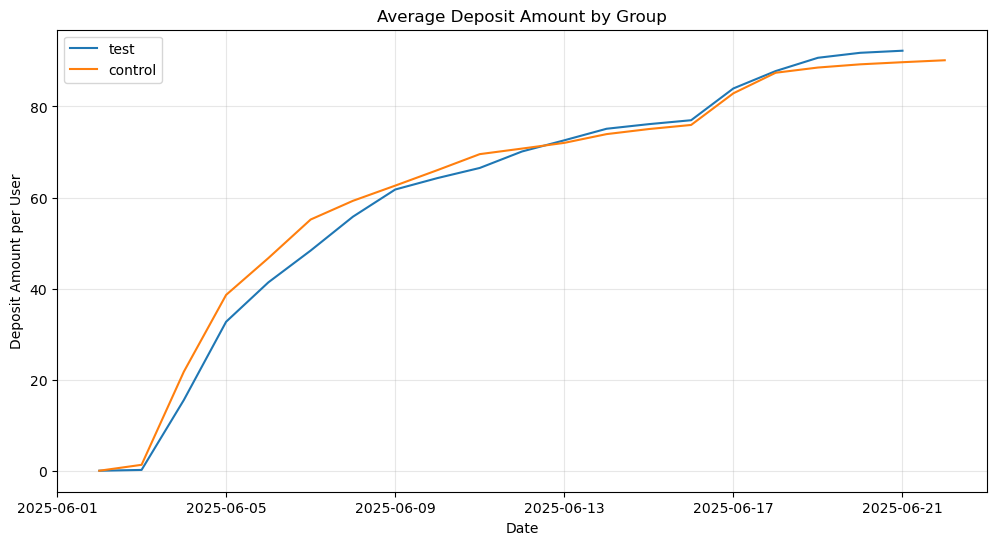

In [76]:
## Let's look at the dynamics
plt.figure(figsize=(12, 6))
all_amounts_gap = []
for group in test_data['group'].unique():
    test_datag = test_data[test_data['group'] == group].copy()
    avg_deposit_g=[]
    amounts_gap = []
    
    test_data_control = test_data[test_data['group'] == 'control'].copy()
    before_dates = sorted(pd.to_datetime(test_datag['event_ts']).dt.date.unique())
    for current_date in before_dates:
        current_date = pd.Timestamp(current_date)
        test_data_date = test_datag[pd.to_datetime(test_datag['event_ts']) <= current_date]
    ## all registered users up to the current date
        users_n=test_data_date['user_id'].nunique()
    ## all purchases up to the current date
        buys_s = test_data_date['amount'].sum()     
    ## key metric for the current date: sum of deposits / number of unique users
        avg_deposit= buys_s/users_n   
        avg_deposit_g.append({
        'date': current_date,
        'avg_deposit': avg_deposit
        })
      
        
    ## linearized for each user
        test_data_date_control = test_data_control[pd.to_datetime(test_data_control['event_ts']) <= current_date]
        avg_day_deposit_control = test_data_date_control['amount'].sum() / test_data_date_control['user_id'].nunique()
        cum_users_amounts = test_data_date.groupby('user_id')['amount'].sum().reset_index(name = 'users_todate_amount')
        amount_gaps = cum_users_amounts['users_todate_amount']-avg_day_deposit_control
        all_amounts_gap.append({'group':group, 'date':current_date, 'gap_array': amount_gaps.values})
        
        
        
    results_df = pd.DataFrame(avg_deposit_g).fillna(0)
    plt.plot(results_df['date'], results_df['avg_deposit'], label = group)
    
plt.title("Average Deposit Amount by Group")
plt.xlabel('Date')
plt.ylabel('Deposit Amount per User')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

all_amounts_gap_df = pd.DataFrame(all_amounts_gap).fillna(0)

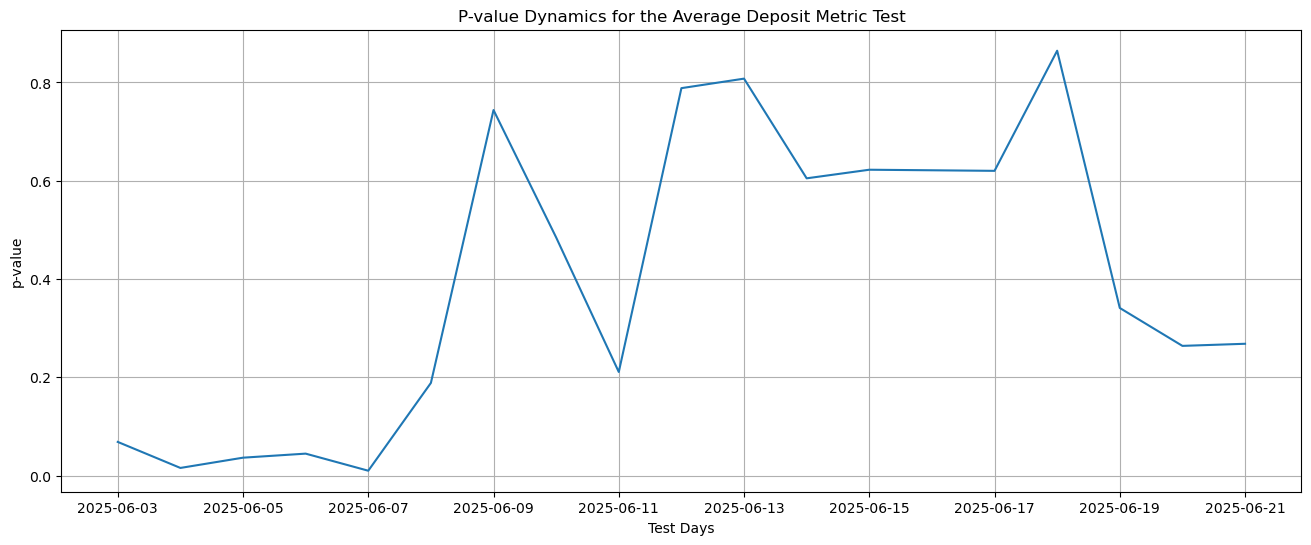

In [77]:
from scipy.stats import ttest_ind
##= all_amounts_gap_df[all_amounts_gap_df['gap_array'].notna()]
test_results = []
for day in sorted(all_amounts_gap_df['date'].unique()):
    df_stat = all_amounts_gap_df[all_amounts_gap_df['date'] == day]
    test_data_p = df_stat[df_stat['group']=='test']
    control_data = df_stat[df_stat['group']=='control']
    if not test_data_p.empty and not control_data.empty:
        test_array = test_data_p['gap_array'].values[0]
        control_array = control_data['gap_array'].values[0]
        if len(test_array) > 0 and len(control_array) > 0:
            _, p_value = ttest_ind(test_array, control_array)
            test_results.append({'date': day, 'p-value': p_value})
test_results_df = pd.DataFrame(test_results)
plt.figure(figsize=(16, 6))
plt.plot(test_results_df['date'], test_results_df['p-value'], label = 'p-value')
plt.xlabel('Test Days') 
plt.ylabel ('p-value')
plt.title ('P-value Dynamics for the Average Deposit Metric Test')
plt.grid(0.3)

The metric is not stable, but the values are high. This indicates strong data volatility. The key metric requires additional analysis approaches because a high p-value does not guarantee accuracy. The negative statistic and the decrease in the average deposit amount are a concerning factor. Next, we will need to examine the sample in more detail and divide it into groups.

##### Guardrail metric — conversion from registration to first deposit.

In [80]:
print(f"\nH0: The distribution of the metric 'conversion from registration to first deposit' is the same in both groups")
print(f"\nH1: The distribution of the metric 'conversion from registration to first deposit' is different")


d=test_data[test_data['event_name']=='registration']
e=test_data[test_data['event_name']=='first_deposit']
f= d.merge(e[['user_id', 'event_name']], on = 'user_id', how = 'left')
f['is_first'] = f['event_name_y'].apply(lambda x: 0 if pd.isna(x) else 1)
test_is_first = f[f['group']=='test']['is_first'].values
control_is_first= f[f['group']=='control']['is_first'].values

  
n_test = len(test_is_first)
n_control = len(control_is_first)
conversions_test = test_is_first.sum()
conversions_control = control_is_first.sum()


n_total = len(test_is_first) + len(control_is_first)
group_count = 2
n = n_total / group_count
degrees_of_freedom = n_total - 2

## stats
mean_test = test_is_first.mean()
mean_control = control_is_first.mean()
std_test = test_is_first.std()
std_control = control_is_first.std()
pooled_std = ((std_test ** 2 + std_control ** 2) / 2) ** 0.5

conversion_test_rate = conversions_test / n_test
conversion_control_rate = conversions_control / n_control
lift = conversion_test_rate - conversion_control_rate
relative_lift = lift / conversion_control_rate

    # Z-test
count = np.array([conversions_test, conversions_control])
nobs = np.array([n_test, n_control])
z_stat, p_value = proportions_ztest(count, nobs)
    
    # Test power calculation
effect_size = abs(lift) / pooled_std if pooled_std > 0 else 0   

if effect_size > 0 and n_test > 0 and n_control > 0:
    power = TTestIndPower().solve_power(
        effect_size=effect_size, 
        nobs1=n_test, 
        alpha=0.1, 
        ratio=n_control/n_test
    )
else:
    power = 0
    
print(f"\n z-statistic = {z_stat:.4f}, p-value = {p_value:.6f}, test power: {power:.3f}")
print(f"conversion from registration to first deposit test % {100*mean_test:.2f}")
print(f"conversion from registration to first deposit control % {100*mean_control:.2f}")
print(f"absolute conversion change % {100*(mean_test-mean_control):.2f}")
print(f"relative conversion change % {100*(mean_test-mean_control)/mean_control:.2f}")


H0: The distribution of the metric 'conversion from registration to first deposit' is the same in both groups

H1: The distribution of the metric 'conversion from registration to first deposit' is different

 z-statistic = -1.5525, p-value = 0.120543, test power: 0.464
conversion from registration to first deposit test % 70.04
conversion from registration to first deposit control % 71.54
absolute conversion change % -1.51
relative conversion change % -2.11


Interpretation. The negative statistic indicates a deterioration in the result. The p-value is close to low values but is less than 10%, meaning the difference is not statistically significant. The power is insufficient; the sample size is too small. The deterioration is not statistically significant.

###### Secondary metric 1: conversion from first deposit to second deposit.

In [83]:
print(f"\nH0: The distribution of the metric 'conversion from first deposit to second deposit' is the same in both groups")
print(f"\nH1: The distribution of the metric 'conversion from first deposit to second deposit' is different")



from statsmodels.stats.power import NormalIndPower
g=test_data[test_data['event_name']=='first_deposit']
h=test_data[test_data['event_name']=='second_deposit']
k= g.merge(h[['user_id', 'event_name']], on = 'user_id', how = 'left')
k['is_second'] = k['event_name_y'].apply(lambda x: 0 if pd.isna(x) else 1)
test_is_second = k[k['group']=='test']['is_second'].values
control_is_second= k[k['group']=='control']['is_second'].values

  
n_test = len(test_is_second)
n_control = len(control_is_second)
conversions_test = test_is_second.sum()
conversions_control = control_is_second.sum()


n_total = len(test_is_second) + len(control_is_second)
group_count = 2
n = n_total / group_count
degrees_of_freedom = n_total - 2

## stats
mean_test = test_is_second.mean()
mean_control = control_is_second.mean()
std_test = test_is_second.std()
std_control = control_is_second.std()
pooled_std = ((std_test ** 2 + std_control ** 2) / 2) ** 0.5

conversion_test_rate = conversions_test / n_test
conversion_control_rate = conversions_control / n_control
lift = conversion_test_rate - conversion_control_rate
relative_lift = lift / conversion_control_rate

    # Z-test
count = np.array([conversions_test, conversions_control])
nobs = np.array([n_test, n_control])
z_stat, p_value = proportions_ztest(count, nobs)
    
    # Test power calculation
effect_size = abs(lift) / pooled_std if pooled_std > 0 else 0
power_calculator = NormalIndPower()
power_proportions = power_calculator.solve_power(
    effect_size=effect_size,
    nobs1=n_test,
    alpha=0.05,
    ratio=n_control/n_test
)
    
print(f"\n z-statistic = {z_stat:.4f}, p-value = {p_value:.6f}, test power: {power:.3f}")
print(f"conversion from registration to first deposit control % {100*mean_control:.2f}")
print(f"conversion from first deposit to second deposit test % {100*mean_test:.2f}")
print(f"absolute conversion change from first to second deposit % {100*(mean_test-mean_control):.2f}")
print(f"relative conversion change from first to second deposit % {100*(mean_test-mean_control)/mean_control:.2f}")


H0: The distribution of the metric 'conversion from first deposit to second deposit' is the same in both groups

H1: The distribution of the metric 'conversion from first deposit to second deposit' is different

 z-statistic = 11.0612, p-value = 0.000000, test power: 0.464
conversion from registration to first deposit control % 20.26
conversion from first deposit to second deposit test % 32.61
absolute conversion change from first to second deposit % 12.35
relative conversion change from first to second deposit % 60.95


Positive statistics, a negligible p-value, and high test power signal a positive dynamic for this metric. However, the test power is insufficient for a reliable result.

##### Secondary Metric 2 — average total deposits per user who opened at least one deposit.

In [86]:
metric = 'average total deposits per user who opened at least one deposit'
print(f"\nH0: The distribution of the metric '{metric}' is the same in both groups")
print(f"\nH1: The distribution of the metric '{metric}' is different\n")


from scipy.stats import ttest_ind

dep_test = test_data[(test_data['amount'].notna()) & (test_data['group']== 'test')]
dep_control = test_data[(test_data['amount'].notna()) & (test_data['group']== 'control')]

dep_amount_test = dep_test.groupby('user_id')['amount'].mean().values
dep_amount_control = dep_control.groupby('user_id')['amount'].mean().values

t_stat, p_value = ttest_ind(dep_amount_test, dep_amount_control, equal_var=False)

dep_amount_test_mean = dep_amount_test.mean()
dep_amount_control_mean = dep_amount_control.mean()
std_test = dep_amount_test.std()
std_control = dep_amount_control.std()
n_test = len(dep_amount_test)
n_control = len(dep_amount_control)

pooled_std = np.sqrt(((n_test - 1) * std_test**2 + (n_control - 1) * std_control**2) / (n_test + n_control - 2))
effect_size = abs(mean_test - mean_control) / pooled_std if pooled_std > 0 else 0

# Test power calculation
power = TTestIndPower().solve_power(
    effect_size=effect_size,
    nobs1=n_test,
    alpha=0.05,
    ratio=n_control/n_test
)

print(f"Test group size: {n_test} , Control group size: {n_control}")
print(f"Test mean: {dep_amount_test_mean:.2f}, Control mean: {dep_amount_control_mean:.2f}")
print(f"Absolute difference: {dep_amount_test_mean - dep_amount_control_mean:.2f}")
print(f"Relative difference %: {(dep_amount_test_mean - dep_amount_control_mean) /dep_amount_control_mean :.2f}")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_value:.6f}")

print(f"Test power: {power:.3f}")


H0: The distribution of the metric 'average total deposits per user who opened at least one deposit' is the same in both groups

H1: The distribution of the metric 'average total deposits per user who opened at least one deposit' is different

Test group size: 2987 , Control group size: 3228
Test mean: 104.42, Control mean: 112.50
Absolute difference: -8.08
Relative difference %: -0.07
T-statistic: -4.3562, p-value: 0.000014
Test power: 0.051


Negative mean values, statistics, and a low p-value indicate a negative change, but the power is low; there is insufficient (too little) data for a complete picture.

---

### 4. Analysis of Changes in Deposit Amounts per Paying User

The new feature could have influenced user behavior.
- Users who previously deposited small amounts might have become more cautious, reduced their investments, or stopped paying altogether. This would be reflected in a decrease in the 25th percentile of deposit amounts in the test group.
- Users inclined towards larger investments might have become more engaged with the product and started depositing more funds. This would be reflected in an increase in the 75th percentile.

Using bootstrap, compare the differences in percentiles (25th, 50th, 75th) of the total deposit amount per paying user in the control and test groups:
- Construct confidence intervals for the difference between the groups for each percentile.
- Interpret the changes in the context of the hypothesis formulated above.
- Visualize the result of the bootstrap test.


H0: The distribution of the metric 'average deposit amount per paying user' is the same in both groups

H1: The distribution of the metric 'average deposit amount per paying user' is different

95% probability contains the true value: [-11.64, -4.40]


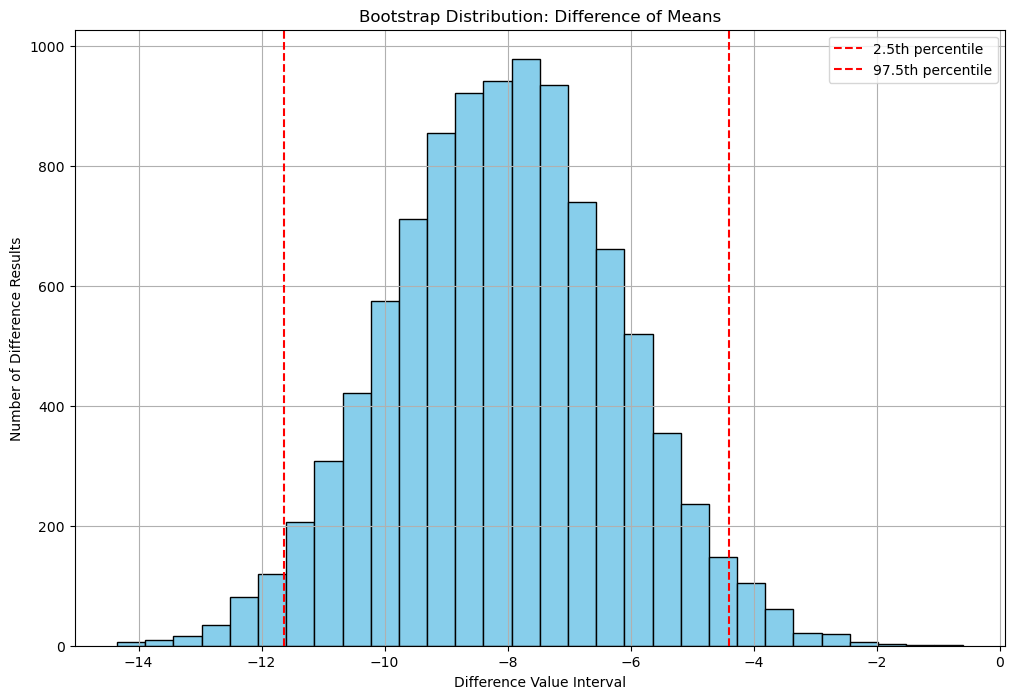

statistic: -4.356233747495056, p-value: 1.3611446895386813e-05
test power: 0.9931502349987315
test group metric value: 104.46, control group metric value: 112.51
absolute change: -8.05
relative change %: -7.15


In [89]:
metric = 'average deposit amount per paying user'
print(f"\nH0: The distribution of the metric '{metric}' is the same in both groups")
print(f"\nH1: The distribution of the metric '{metric}' is different\n")


np.random.seed(42)
array_control = np.array(dep_amount_control)
array_test = np.array(dep_amount_test)
n_iterations = 10000
boot_diffs=[]
n_control = len(array_control)
n_test  = len(array_test)
boot_means_control = []
boot_means_test = []
for _ in range(n_iterations):
   boot_control = np.random.choice(array_control, size=n_control, replace=True)
   boot_test = np.random.choice(array_test, size=n_test, replace=True)
   mean_control = np.mean(boot_control)
   boot_means_control.append(mean_control)
   mean_test = np.mean(boot_test)
   boot_means_test.append(mean_test)
   boot_diffs.append(mean_test - mean_control)

boot_means_control=np.array(boot_means_control)
boot_means_test=np.array(boot_means_test)
boot_diffs = np.array(boot_diffs)
mean_diff_ci = np.percentile(boot_diffs, [2.5, 97.5])
print(f"95% probability contains the true value: [{mean_diff_ci[0]:.2f}, {mean_diff_ci[1]:.2f}]")
plt.figure(figsize=(12, 8))
plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(mean_diff_ci[0], color='red', linestyle='--', label='2.5th percentile')
plt.axvline(mean_diff_ci[1], color='red', linestyle='--', label='97.5th percentile')
plt.title("Bootstrap Distribution: Difference of Means")
plt.legend()
plt.grid()
plt.xlabel('Difference Value Interval')
plt.ylabel('Number of Difference Results')
plt.show()

t_stat, p_value_ttest = ttest_ind(array_test, array_control, equal_var=False)
# Test power calculation
effect_size = (np.mean(array_test) - np.mean(array_control)) / np.sqrt(
    (np.var(array_test, ddof=1) + np.var(array_control, ddof=1)) / 2
)
power_analysis = TTestIndPower()
power = power_analysis.solve_power(
    effect_size=effect_size,
    nobs1=n_test,
    alpha=0.05,
    ratio=n_control/n_test
)

print(f"statistic: {t_stat}, p-value: {p_value_ttest}")
print(f"test power: {power}")
print(f"test group metric value: {boot_means_test.mean():.2f}, control group metric value: {boot_means_control.mean():.2f}")
print(f"absolute change: {boot_means_test.mean() - boot_means_control.mean():.2f}")
print(f"relative change %: { 100* (boot_means_test.mean() - boot_means_control.mean() ) / boot_means_control.mean()  :.2f}")

A negative difference with values below zero indicates a decrease in the average deposit indicator in the test group relative to the control group.

Using iterations of random samples, test -4.356233747495056, p-value 1.361144689538681e-05 means the difference is statistically significant.

The test power with this sample size is high at 99%. This means a low risk of false negative results and high sensitivity. This is expected with the bootstrap method, as random values were taken from 10,000 iterations.

Check on the sample of users at the 25th percentile.


H0: The distribution of the 25th percentile of the metric 'average deposit amount per paying user' is the same in both groups

H1: The distribution of the 25th percentile of the metric 'average deposit amount per paying user' is different

95% probability contains the true value: [-52.38, -48.75]


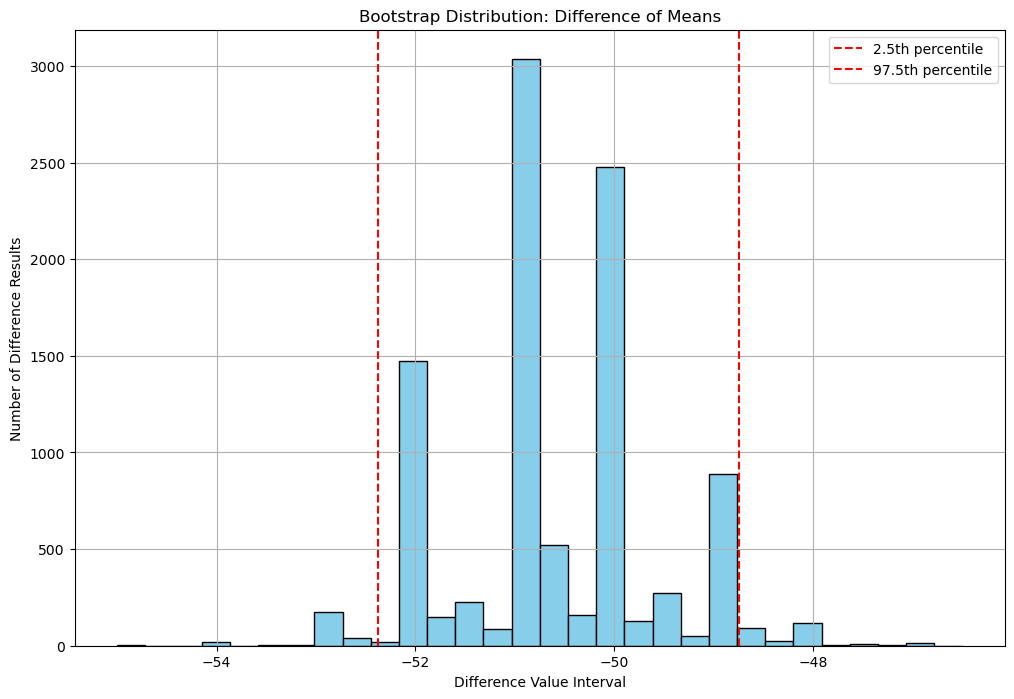

statistic: -4936.512577908374, p-value: 0.0
25th percentile test group: 41.0, 25th percentile control group: 91.0
control group metric: 91.43, test group metric: 40.80
absolute change: -50.63
relative change %: -55.37


In [92]:
metric = 'average deposit amount per paying user'
perc = 25
print(f"\nH0: The distribution of the {perc}th percentile of the metric '{metric}' is the same in both groups")
print(f"\nH1: The distribution of the {perc}th percentile of the metric '{metric}' is different\n")

np.random.seed(42)
array_control = np.array(dep_amount_control)
array_test = np.array(dep_amount_test)
percentile_25_control = np.percentile(array_control, 25)
percentile_25_test = np.percentile(array_test, 25)
n_iterations = 10000
boot_diffs=[]

boot_perc_25_test_store = []
boot_perc_25_control_store = []

for _ in range(n_iterations):
   boot_control = np.random.choice(array_control, size=len(array_control), replace=True)
   boot_perc_25_control = np.percentile(boot_control, 25)
    
   boot_test = np.random.choice(array_test, size=len(array_test), replace=True)
   boot_perc_25_test = np.percentile(boot_test, 25)
    
   boot_diffs.append(boot_perc_25_test - boot_perc_25_control)

   boot_perc_25_test_store.append(boot_perc_25_test)
   boot_perc_25_control_store.append(boot_perc_25_control)

boot_perc_25_test_set = np.array(boot_perc_25_test_store)  
boot_perc_25_control_set = np.array(boot_perc_25_control_store) 
t_stat, p_value_ttest = ttest_ind(boot_perc_25_test_set, boot_perc_25_control_set, equal_var=False)

boot_diffs = np.array(boot_diffs)
mean_diff_ci = np.percentile(boot_diffs, [2.5, 97.5])
print(f"95% probability contains the true value: [{mean_diff_ci[0]:.2f}, {mean_diff_ci[1]:.2f}]")
plt.figure(figsize=(12, 8))
plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(mean_diff_ci[0], color='red', linestyle='--', label='2.5th percentile')
plt.axvline(mean_diff_ci[1], color='red', linestyle='--', label='97.5th percentile')
plt.title("Bootstrap Distribution: Difference of Means")
plt.xlabel('Difference Value Interval')
plt.ylabel('Number of Difference Results')
plt.legend()
plt.grid()
plt.show()

print(f"statistic: {t_stat}, p-value: {p_value_ttest}\n25th percentile test group: {percentile_25_test}, 25th percentile control group: {percentile_25_control}")
print(f"control group metric: {boot_perc_25_control_set.mean():.2f}, test group metric: {boot_perc_25_test_set.mean():.2f}")
print(f"absolute change: {boot_perc_25_test_set.mean()- boot_perc_25_control_set.mean():.2f}")
print(f"relative change %: { 100* (boot_perc_25_test_set.mean()- boot_perc_25_control_set.mean() ) /boot_perc_25_control_set.mean():.2f}")

The difference is huge. This is the result of users who deposited small amounts significantly lowering their deposit level!


H0: The distribution of the 50th percentile of the metric 'average deposit amount per paying user' is the same in both groups

H1: The distribution of the 50th percentile of the metric 'average deposit amount per paying user' is different

95% probability contains the true value: [-39.00, -32.25]


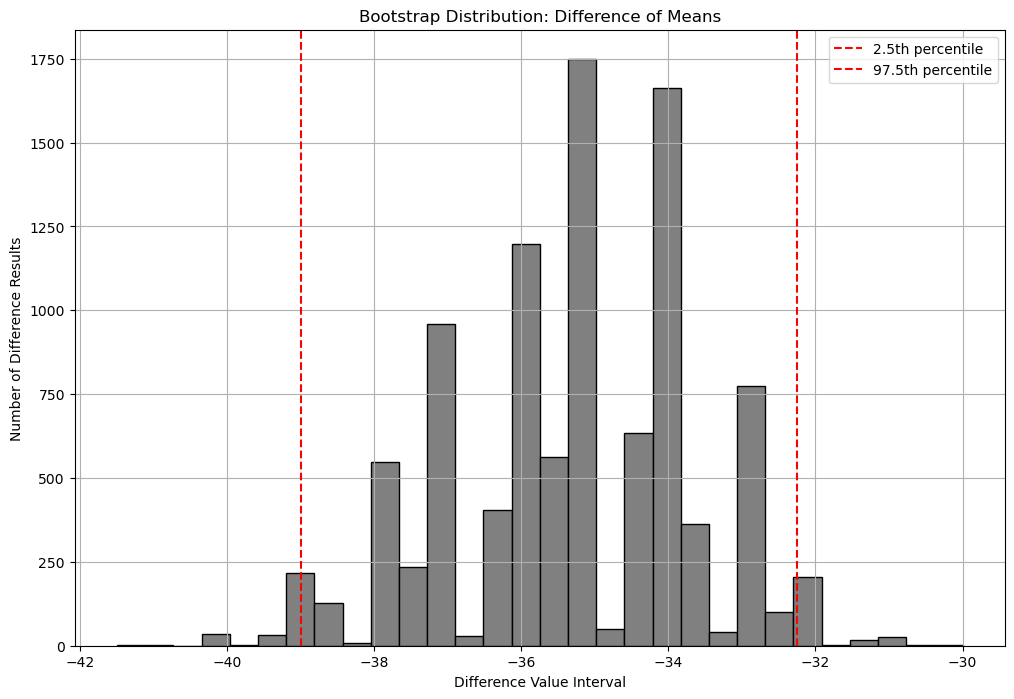

statistic: -2118.436923966258, p-value: 0.0
50th percentile test group: 74.0, 50th percentile control group: 109.0
absolute change: -35.28
relative change %: -32.44


In [94]:
metric = 'average deposit amount per paying user'
perc = 50
print(f"\nH0: The distribution of the {perc}th percentile of the metric '{metric}' is the same in both groups")
print(f"\nH1: The distribution of the {perc}th percentile of the metric '{metric}' is different\n")


np.random.seed(42)
array_control = np.array(dep_amount_control)
array_test = np.array(dep_amount_test)
percentile_50_control = np.percentile(array_control, 50)
percentile_50_test = np.percentile(array_test, 50)
n_iterations = 10000
boot_diffs=[]

boot_perc_50_test_store = []
boot_perc_50_control_store = []

for _ in range(n_iterations):
   boot_control = np.random.choice(array_control, size=len(array_control), replace=True)
   boot_perc_50_control = np.percentile(boot_control, 50)
    
   boot_test = np.random.choice(array_test, size=len(array_test), replace=True)
   boot_perc_50_test = np.percentile(boot_test, 50)
    
   boot_diffs.append(boot_perc_50_test - boot_perc_50_control)

   boot_perc_50_test_store.append(boot_perc_50_test)
   boot_perc_50_control_store.append(boot_perc_50_control)

boot_perc_50_test_set = np.array(boot_perc_50_test_store)  
boot_perc_50_control_set = np.array(boot_perc_50_control_store) 
t_stat, p_value_ttest = ttest_ind(boot_perc_50_test_set, boot_perc_50_control_set, equal_var=False)

boot_diffs = np.array(boot_diffs)
mean_diff_ci = np.percentile(boot_diffs, [2.5, 97.5]) # Confidence intervals (by percentiles)
print(f"95% probability contains the true value: [{mean_diff_ci[0]:.2f}, {mean_diff_ci[1]:.2f}]")
plt.figure(figsize=(12, 8))
plt.hist(boot_diffs, bins=30, color='gray', edgecolor='black')
plt.axvline(mean_diff_ci[0], color='red', linestyle='--', label='2.5th percentile')
plt.axvline(mean_diff_ci[1], color='red', linestyle='--', label='97.5th percentile')
plt.title("Bootstrap Distribution: Difference of Means")
plt.xlabel('Difference Value Interval')
plt.ylabel('Number of Difference Results')
plt.legend()
plt.grid()
plt.show()


print(f"statistic: {t_stat}, p-value: {p_value_ttest}\n50th percentile test group: {percentile_50_test}, 50th percentile control group: {percentile_50_control}")
print(f"absolute change: {boot_perc_50_test_set.mean()- boot_perc_50_control_set.mean():.2f}")
print(f"relative change %: { 100* (boot_perc_50_test_set.mean()- boot_perc_50_control_set.mean()) /boot_perc_50_control_set.mean() :.2f}")

The gap in the median value also persists, with a difference of -39 : -32.5.


H0: The distribution of the 75th percentile of the metric 'average deposit amount per paying user' is the same in both groups

H1: The distribution of the 75th percentile of the metric 'average deposit amount per paying user' is different

95% probability contains the true value: [-3.00, 7.00]


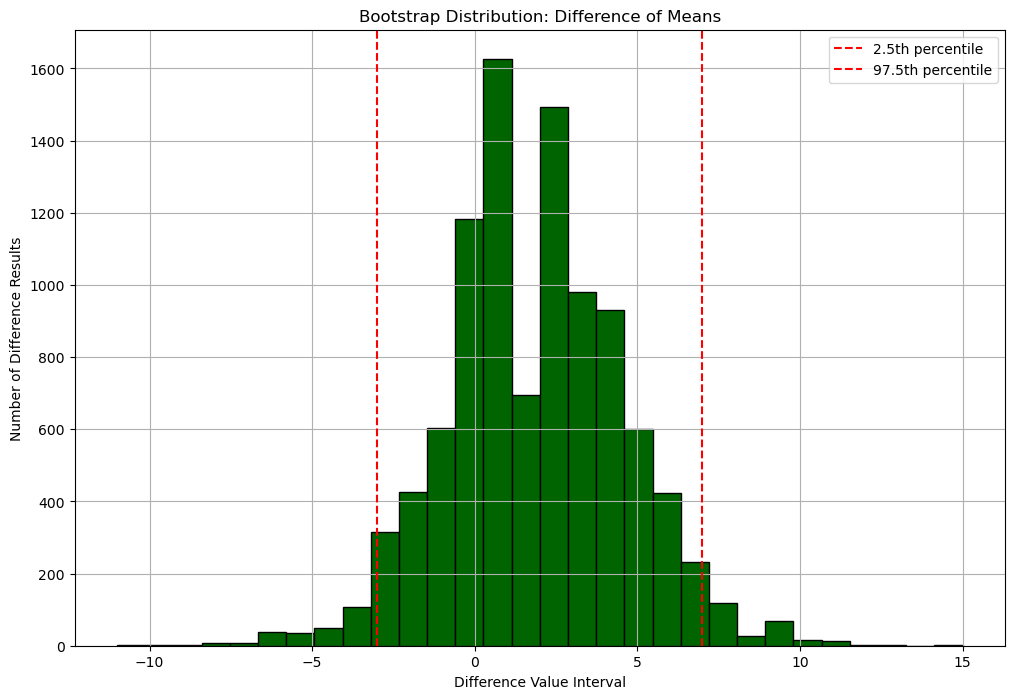

statistic: 68.00363309548784, p-value: 0.0
75th percentile test group: 131.0, 75th percentile control group: 129.625
absolute change: 1.83
relative change %: 1.41


In [96]:
metric = 'average deposit amount per paying user'
perc = 75
print(f"\nH0: The distribution of the {perc}th percentile of the metric '{metric}' is the same in both groups")
print(f"\nH1: The distribution of the {perc}th percentile of the metric '{metric}' is different\n")


np.random.seed(42)
array_control = np.array(dep_amount_control)
array_test = np.array(dep_amount_test)
percentile_75_control = np.percentile(array_control, 75)
percentile_75_test = np.percentile(array_test, 75)
n_iterations = 10000
boot_diffs=[]

boot_perc_75_test_store = []
boot_perc_75_control_store = []

for _ in range(n_iterations):
   boot_control = np.random.choice(array_control, size=len(array_control), replace=True)
   boot_perc_75_control = np.percentile(boot_control, 75)
    
   boot_test = np.random.choice(array_test, size=len(array_test), replace=True)
   boot_perc_75_test = np.percentile(boot_test, 75)
    
   boot_diffs.append(boot_perc_75_test - boot_perc_75_control)

   boot_perc_75_test_store.append(boot_perc_75_test)
   boot_perc_75_control_store.append(boot_perc_75_control)

boot_perc_75_test_set = np.array(boot_perc_75_test_store)  
boot_perc_75_control_set = np.array(boot_perc_75_control_store) 
t_stat, p_value_ttest = ttest_ind(boot_perc_75_test_set, boot_perc_75_control_set, equal_var=False)

boot_diffs = np.array(boot_diffs)
mean_diff_ci = np.percentile(boot_diffs, [2.5, 97.5])
print(f"95% probability contains the true value: [{mean_diff_ci[0]:.2f}, {mean_diff_ci[1]:.2f}]")
plt.figure(figsize=(12, 8))
plt.hist(boot_diffs, bins=30, color='darkgreen', edgecolor='black')
plt.axvline(mean_diff_ci[0], color='red', linestyle='--', label='2.5th percentile')
plt.axvline(mean_diff_ci[1], color='red', linestyle='--', label='97.5th percentile')
plt.title("Bootstrap Distribution: Difference of Means")
plt.xlabel('Difference Value Interval')
plt.ylabel('Number of Difference Results')
plt.legend()
plt.grid()
plt.show()


print(f"statistic: {t_stat}, p-value: {p_value_ttest}\n75th percentile test group: {percentile_75_test}, 75th percentile control group: {percentile_75_control}")
print(f"absolute change: {boot_perc_75_test_set.mean()- boot_perc_75_control_set.mean():.2f}")
print(f"relative change %: { 100* (boot_perc_75_test_set.mean()- boot_perc_75_control_set.mean()) /boot_perc_75_control_set.mean() :.2f}")

---

### 5. Conclusions

1.  **Analysis before testing:** Data analysis was conducted before the test, and correlations between countries were checked. It was found that the difference between countries is minimal. Most importantly, the deposit dynamics show synchronous movement over time. Therefore, the analysis is universal, and there is no point in breaking it down by country.

2.  **Test and event funnel:** The test was conducted, and the event funnel showed an increase in conversion to the second deposit for the high-risk asset, from 28% to 47% of the previous step. This is a positive effect of the feature. However, the number of users does not imply an improvement in the total deposit amount or the average amount per user. Therefore, an analysis of the product metrics was carried out next.

3.  **Key Metric (Deposit amount per user):** The calculation gave a negative result for the average deposit amount.
    *   z-statistic = -1.5525, p-value = 0.120543, test power: 0.464
    *   Average deposit amount per user in the control group: 46.45
    *   Average deposit amount per user in the test group: 44.86
    *   Absolute change: -1.59
    *   Relative change %: -3.43
    *   A negative dynamic (decrease) was identified, but the test power with this sample size did not confirm the result as reliable, as the sample (4.5 - 4.8 thousand test users) is insufficient. The p-value analysis for the key metric of the control and test groups was unstable throughout the test, fluctuating from 0 to 0.8. Therefore, alternative methods of segmentation and data scaling were subsequently applied.

4.  **Guardrail Metric (Conversion from registration to first deposit):**
    *   z-statistic = -1.5525, p-value = 0.120543, test power: 0.464
    *   Conversion from registration to first deposit (test) %: 70.04
    *   Conversion from registration to first deposit (control) %: 71.54
    *   Absolute conversion change %: -1.51
    *   Relative conversion change %: -2.11
    *   The change is also negative. However, the test power is insufficient. It could be scaled if necessary, but if the key metric is falling and the decline is statistically confirmed, other tests become irrelevant.

5.  **Secondary Metrics:**
    *   **Conversion from first deposit to second deposit:**
        *   z-statistic = 11.0612, p-value = 0.000000, test power: 0.464
        *   Conversion from registration to first deposit (control) %: 20.26
        *   Conversion from first deposit to second deposit (test) %: 32.61
        *   Absolute conversion change (first to second deposit) %: 12.35
        *   Relative conversion change (first to second deposit) %: 60.95
        *   In this case, the dynamic is positive. However, the insight is that this does not lead to an increase in deposit amounts; on the contrary, the effect is opposite. The power is too low.
    *   **Secondary Metric 2 (Average total deposits per user who opened at least one deposit):**
        *   Test mean: 104.42, Control mean: 112.50
        *   Absolute difference: -8.08
        *   Relative difference %: -0.07
        *   T-statistic: -4.3562, p-value: 0.000014
        *   Test power: 0.051
        *   The dynamic is negative with minimal power. However, seeking insights when the key metric is deteriorating is pointless.

6.  **In-depth analysis with percentiles and bootstrap:** For a deeper understanding of what is happening with the deposit amount, segments by percentiles were studied. Due to a lack of data, the bootstrap method was applied. Random values were taken to construct series with differences between the metric data of the compared groups. This provided sufficient statistical data volume. The analysis was based on the assumptions that users with low amounts started splitting even less, while those with high amounts started increasing, and data for paying users was obtained.

    *   **Without segmentation (overall picture):** Overall, the indicator worsened.
        *   Test group metric value: 104.46, Control group metric value: 112.51
        *   Absolute change: -8.05
        *   Relative change %: -7.15
    *   **25th Percentile Segment:** Indeed, a huge decrease; the feature causes an adverse effect.
        *   Control group metric: 91.43, Test group metric: 40.80
        *   Absolute change: -50.63
        *   Relative change %: -55.37
    *   **50th Percentile Segment:** The gap narrows.
        *   50th percentile test group: 74.0, 50th percentile control group: 109.0
        *   Absolute change: -35.28
        *   Relative change %: -32.44
    *   **75th Percentile Segment:** Indicators almost converged.
        *   75th percentile test group: 131.0, 75th percentile control group: 129.6
        *   Absolute change: 1.83
        *   Relative change %: 1.41

    This confirms that users with small deposits reduced their deposit amounts! The feature works in two opposite directions: it improves the deposit size for users with large amounts (those initially willing to take risks by making a large deposit) and deters cautious users. For an overall positive effect, it requires fine-tuning.

###### Recommendations

So, the feature increases conversion for the risky asset but decreases deposit amounts. Its impact on the average level is negative. It is recommended to modify this feature so that clients continue to use the service without reducing their purchase amounts. This could involve presenting information in a more concise format, adding success stories, or offering bonuses to paying clients in the form of ready-made strategies.

Furthermore, an unevenness effect was detected where the distribution graph of the difference from the average deposit amount by percentiles looks like a "fence," meaning individual elements of the feature sharply impact the amount. For example, the difference for 34.8 is 30 users, while at 35.2 it is 1750 users. This suggests that individual elements of the feature have a point-like effect on the amount (possibly due to banners like "top up by ... amount"). In that case, as an option, the button banner could be changed to a wheel. Such an insight requires separate testing; the product manager might provide direction.

A separate task for improvement is smoothing out the variations (the standard deviation indicator).